### בדיקה 24.5.26 בדיקה אמפירית

In [18]:
import pandas as pd
import numpy as np

# =====================================================================
# 1. הגדרת פונקציית עיבוד הנתונים (prepare_data) - גרסה B: בלי budget
# =====================================================================

def prepare_data(df):
    """
    מקבלת DataFrame גולמי ומחזירה DataFrame מעובד עם הפיצ'רים בלבד.
    הפונקציה דטרמיניסטית ועובדת גם על שורה בודדת וגם על אלפי שורות.
    """
    data = df.copy()
    data.columns = data.columns.str.strip()

    # --- 1. מניעת Data Leakage: הסרת שדות שלא קיימים בזמן יציאת הסרט ---
    leakage_cols = ['averageRating', 'numVotes', 'BoxOffice']
    data = data.drop(columns=[c for c in leakage_cols if c in data.columns],
                     errors='ignore')

    # --- 2. ניקוי עמודות נומריות ---
    # ניקוי runtimeMinutes
    if 'runtimeMinutes' in data.columns:
        data['runtimeMinutes'] = data['runtimeMinutes'].astype(str).replace(r'\N', np.nan)
        data['runtimeMinutes'] = pd.to_numeric(data['runtimeMinutes'], errors='coerce')

    # ניקוי startYear - גם ערכי 0 לא הגיוניים
    if 'startYear' in data.columns:
        data['startYear'] = data['startYear'].astype(str).replace(r'\N', np.nan)
        data['startYear'] = pd.to_numeric(data['startYear'], errors='coerce')
        data.loc[data['startYear'] <= 0, 'startYear'] = np.nan

    # ניקוי עמודת genres - בדאטה יש שני פורמטים מעורבים:
    # חלק מהשורות שמורות כ-"Drama,Comedy" וחלק כ-"['Drama', 'Comedy']"
    # נסיר את הסוגריים והגרשיים כדי לאחד את הפורמט
    if 'genres' in data.columns:
        data['genres'] = data['genres'].astype(str)
        data['genres'] = data['genres'].str.replace(r"[\[\]'\"]", '', regex=True)
        data['genres'] = data['genres'].replace(r'\N', np.nan)

    # --- 3. Feature Engineering ---

    # פיצ'ר 1: מספר הז'אנרים של הסרט
    data['num_genres'] = data['genres'].apply(
        lambda x: len(str(x).split(',')) if pd.notnull(x) else 0
    )

    # פיצ'ר 2: הז'אנר הראשי
    data['primary_genre'] = data['genres'].apply(
        lambda x: str(x).split(',')[0].strip() if pd.notnull(x) else 'Unknown'
    )

    # פיצ'רים 3-5: סימון אם הסרט שייך לז'אנרים נפוצים (גם אם זה לא הז'אנר הראשי)
    # ה-primary_genre לוקח רק את הראשון, אבל המידע על שאר הז'אנרים גם חשוב
    data['is_drama'] = data['genres'].apply(
        lambda x: int('Drama' in str(x)) if pd.notnull(x) else 0
    )
    data['is_comedy'] = data['genres'].apply(
        lambda x: int('Comedy' in str(x)) if pd.notnull(x) else 0
    )
    data['is_documentary'] = data['genres'].apply(
        lambda x: int('Documentary' in str(x)) if pd.notnull(x) else 0
    )

    # פיצ'ר 6: האם הסרט מארה"ב - מטפל גם במקרה של כמה מדינות מופרדות בפסיק
    if 'Country' in data.columns:
        data['is_US'] = data['Country'].apply(
            lambda x: int(any(c.strip() in ['US', 'USA', 'United States']
                              for c in str(x).split(','))) if pd.notnull(x) else 0
        )
    else:
        data['is_US'] = 0

    # פיצ'ר 7: מספר המדינות המעורבות בהפקה - פרוקסי לגודל ההפקה
    if 'Country' in data.columns:
        data['num_countries'] = data['Country'].apply(
            lambda x: len(str(x).split(',')) if pd.notnull(x) and str(x) != r'\N' else 0
        )
    else:
        data['num_countries'] = 0

    # פיצ'ר 8: עשור היציאה (binning) - פיצ'ר נומרי מורכב
    data['release_decade'] = (data['startYear'] // 10) * 10

    # פיצ'ר 9: אורך התקציר במילים - פרוקסי לעומק/השקעה בשיווק
    if 'plot' in data.columns:
        data['plot_length'] = data['plot'].apply(
            lambda x: len(str(x).split()) if pd.notnull(x) and str(x) != r'\N' else 0
        )
    else:
        data['plot_length'] = 0

    # חגורת בטיחות: הסרת ערכי אינסוף שעלולים להיווצר מחלוקות
    data = data.replace([np.inf, -np.inf], np.nan)

    # --- 4. הסרת עמודות גולמיות מיותרות (משאירים את startYear) ---
    # שים לב: זרקנו את budget ואת lead_actors_ids מהמודל
    raw_cols_to_drop = ['tconst', 'primaryTitle', 'genres', 'lead_actors_ids',
                        'plot', 'Country', 'Language', 'budget']
    data = data.drop(columns=[c for c in raw_cols_to_drop if c in data.columns],
                     errors='ignore')

    return data


# =====================================================================
# 2. הרצת הקוד: טעינת הקובץ והפעלת הפונקציה
# =====================================================================
try:
    print("קורא את קובץ הנתונים...")
    raw_df = pd.read_csv('dataset.csv')
    raw_df.columns = raw_df.columns.str.strip()
    print(f"הקובץ נטען בהצלחה! מספר שורות גולמי: {raw_df.shape[0]}")

    # סינון שורות בלי טרגט לפני חילוץ y
    df_clean = raw_df.dropna(subset=['averageRating']).copy()
    print(f"מספר שורות לאימון לאחר הסרת סרטים ללא דירוג: {df_clean.shape[0]}")

    y = df_clean['averageRating']
    X = prepare_data(df_clean)

    print("\n=== 1. סוגי הנתונים (dtypes) ===")
    print(X.dtypes)

    print("\n=== 2. כמות ערכים חסרים בכל פיצ'ר ===")
    print(X.isnull().sum())

    print("\n=== 3. תצוגה מקדימה של X ===")
    display(X.head())

    # בדיקה שהפונקציה עובדת על שורה בודדת (דרישה במטלה)
    print("\n=== 4. בדיקת תאימות לשורה בודדת ===")
    single_row = raw_df.head(1).copy()
    single_output = prepare_data(single_row)
    print(f"שורה בודדת עברה בהצלחה. ממדי הפלט: {single_output.shape}")

except FileNotFoundError:
    print("שגיאה: הקובץ 'dataset.csv' לא נמצא.")

קורא את קובץ הנתונים...


C:\Users\user\AppData\Local\Temp\ipykernel_11300\1532113828.py:111: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv('dataset.csv')


הקובץ נטען בהצלחה! מספר שורות גולמי: 133884
מספר שורות לאימון לאחר הסרת סרטים ללא דירוג: 115560

=== 1. סוגי הנתונים (dtypes) ===
startYear         float64
runtimeMinutes    float64
num_genres          int64
primary_genre      object
is_drama            int64
is_comedy           int64
is_documentary      int64
is_US               int64
num_countries       int64
release_decade    float64
plot_length         int64
dtype: object

=== 2. כמות ערכים חסרים בכל פיצ'ר ===
startYear         1
runtimeMinutes    0
num_genres        0
primary_genre     0
is_drama          0
is_comedy         0
is_documentary    0
is_US             0
num_countries     0
release_decade    1
plot_length       0
dtype: int64

=== 3. תצוגה מקדימה של X ===


,startYear,runtimeMinutes,num_genres,primary_genre,is_drama,is_comedy,is_documentary,is_US,num_countries,release_decade,plot_length
0,1993.0,90.0,3,Crime,1,0,0,0,1,1990.0,0
1,2024.0,86.0,1,Drama,1,0,0,0,0,2020.0,0
4,2006.0,102.0,1,Comedy,0,1,0,0,0,2000.0,0
7,2011.0,85.0,3,Biography,0,0,1,0,0,2010.0,0
8,1993.0,170.0,1,Documentary,0,0,1,0,0,1990.0,0



=== 4. בדיקת תאימות לשורה בודדת ===
שורה בודדת עברה בהצלחה. ממדי הפלט: (1, 11)


C:\Users\user\AppData\Local\Temp\ipykernel_11300\1532113828.py:94: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace([np.inf, -np.inf], np.nan)


In [19]:
# =====================================================================
# תא 4: בניית Pipeline ואימון מודל Elastic Net
# =====================================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score

# חלוקת הפיצ'רים לפי סוגי הנתונים
numeric_cols = X.select_dtypes('number').columns.tolist()
categorical_cols = X.select_dtypes('object').columns.tolist()

# Pipeline לפיצ'רים נומריים: השלמת חסרים בחציון + נרמול
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline לפיצ'רים קטגוריאליים: השלמת חסרים + One-Hot Encoding
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# איחוד שני ה-Pipelines ל-ColumnTransformer אחד
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

# ה-Pipeline המלא: עיבוד מקדים + מודל Elastic Net
elastic_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', ElasticNet(random_state=42, max_iter=5000))
])

In [20]:
# הגדרת רשת הפרמטרים ל-Tuning של alpha ו-l1_ratio
param_grid = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0],
    'model__l1_ratio': [0.2, 0.5, 0.8]
}

# הגדרת 10-Fold Cross Validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# חיפוש הפרמטרים המיטביים לפי RMSE
grid_search = GridSearchCV(elastic_pipe, param_grid, cv=cv,
                           scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X, y)

best_elastic_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

Best parameters: {'model__alpha': 0.01, 'model__l1_ratio': 0.2}


In [21]:
# הערכת המודל הטוב ביותר ב-10-Fold CV על שלושת המדדים
rmse_scores = -cross_val_score(best_elastic_model, X, y, cv=cv,
                                scoring='neg_root_mean_squared_error')
mae_scores = -cross_val_score(best_elastic_model, X, y, cv=cv,
                               scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(best_elastic_model, X, y, cv=cv, scoring='r2')

print(f"RMSE: {rmse_scores.mean():.4f} (± {rmse_scores.std():.4f})")
print(f"MAE:  {mae_scores.mean():.4f} (± {mae_scores.std():.4f})")
print(f"R²:   {r2_scores.mean():.4f} (± {r2_scores.std():.4f})")

RMSE: 1.1459 (± 0.0093)
MAE:  0.8783 (± 0.0064)
R²:   0.2143 (± 0.0065)


In [23]:
# =====================================================================
# תא 5: בניית Pipeline ואימון מודל Random Forest
# =====================================================================
from sklearn.ensemble import RandomForestRegressor

# ה-Pipeline המלא: עיבוד מקדים + מודל Random Forest
# משתמשים באותו preprocessor שהגדרנו בתא 4
rf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=2))
])

In [24]:
# הגדרת רשת הפרמטרים ל-Tuning של ההיפר-פרמטרים העיקריים של Random Forest
param_grid_rf = {
    'model__n_estimators': [100],
    'model__max_depth': [10, 20],
    'model__min_samples_leaf': [5]
}

# חיפוש הפרמטרים המיטביים לפי RMSE
grid_search_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=cv,
                              scoring='neg_root_mean_squared_error', n_jobs=1)
grid_search_rf.fit(X, y)

best_rf_model = grid_search_rf.best_estimator_
print("Best parameters:", grid_search_rf.best_params_)

Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}


In [25]:
# הערכת המודל הטוב ביותר ב-10-Fold CV על שלושת המדדים
rmse_scores_rf = -cross_val_score(best_rf_model, X, y, cv=cv,
                                   scoring='neg_root_mean_squared_error', n_jobs=1)
mae_scores_rf = -cross_val_score(best_rf_model, X, y, cv=cv,
                                  scoring='neg_mean_absolute_error', n_jobs=1)
r2_scores_rf = cross_val_score(best_rf_model, X, y, cv=cv, scoring='r2', n_jobs=1)

print(f"RMSE: {rmse_scores_rf.mean():.4f} (± {rmse_scores_rf.std():.4f})")
print(f"MAE:  {mae_scores_rf.mean():.4f} (± {mae_scores_rf.std():.4f})")
print(f"R²:   {r2_scores_rf.mean():.4f} (± {r2_scores_rf.std():.4f})")

RMSE: 1.1191 (± 0.0090)
MAE:  0.8540 (± 0.0063)
R²:   0.2506 (± 0.0064)


In [26]:
#### Error Analysis 

In [27]:
# =====================================================================
# תא 6: Error Analysis - חישוב תחזיות out-of-fold לשני המודלים
# =====================================================================
from sklearn.model_selection import cross_val_predict

# קבלת תחזיות לכל סרט מ-CV (כל סרט מקבל תחזית ממודל שלא ראה אותו באימון)
print("מחשב תחזיות עבור Elastic Net...")
y_pred_elastic = cross_val_predict(best_elastic_model, X, y, cv=cv, n_jobs=1)

print("מחשב תחזיות עבור Random Forest...")
y_pred_rf = cross_val_predict(best_rf_model, X, y, cv=cv, n_jobs=1)

print("\nהתחזיות מוכנות!")
print(f"מספר תחזיות עבור כל מודל: {len(y_pred_elastic)}")

מחשב תחזיות עבור Elastic Net...
מחשב תחזיות עבור Random Forest...

התחזיות מוכנות!
מספר תחזיות עבור כל מודל: 115560


In [30]:
# חישוב השגיאות (תחזית - אמת)
# שגיאה חיובית = overprediction (המודל חזה גבוה מדי)
# שגיאה שלילית = underprediction (המודל חזה נמוך מדי)
errors_elastic = y_pred_elastic - y.values
errors_rf = y_pred_rf - y.values

# יצירת DataFrame להשוואה עם המידע המקורי של הסרטים
results_df = df_clean.copy()
results_df['y_true'] = y.values
results_df['pred_elastic'] = y_pred_elastic
results_df['pred_rf'] = y_pred_rf
results_df['error_elastic'] = errors_elastic
results_df['error_rf'] = errors_rf

# ניקוי עמודת genres - אותו ניקוי כמו ב-prepare_data, כדי לראות פורמט אחיד
results_df['genres'] = (results_df['genres']
                       .astype(str)
                       .str.replace(r"[\[\]'\"]", '', regex=True))

print("דוגמה לטבלת התוצאות:")
display(results_df[['primaryTitle', 'startYear', 'genres', 'y_true',
                    'pred_rf', 'error_rf']].head())

דוגמה לטבלת התוצאות:


,primaryTitle,startYear,genres,y_true,pred_rf,error_rf
0,Johnny One Hundred Pesos,1993.0,"Crime,Drama,Thriller",6.6,5.781885,-0.818115
1,It Doesn't Matter,2024.0,Drama,6.1,6.120533,0.020533
4,"If You Love Me, Follow Me",2006.0,Comedy,6.1,5.573031,-0.526969
7,I Want My Name Back,2011.0,"Biography,Documentary,Music",7.0,7.254123,0.254123
8,Itgaber: Le triomphe sur soi,1993.0,Documentary,9.2,7.469439,-1.730561


In [31]:
# =====================================================================
# חילוץ 20 ה-outliers הגדולים של Random Forest (המודל הטוב יותר)
# =====================================================================

# מיון לפי שגיאה
# 10 הסרטים עם overprediction הגדול ביותר (שגיאה חיובית גדולה)
top_over_rf = results_df.nlargest(10, 'error_rf')

# 10 הסרטים עם underprediction הגדול ביותר (שגיאה שלילית גדולה)
top_under_rf = results_df.nsmallest(10, 'error_rf')

# הצגת overpredictions
print("=" * 70)
print("10 הסרטים עם ה-OVERPREDICTION הגדול ביותר")
print("(המודל חזה גבוה מדי - סרטים גרועים שהמודל חשב שטובים)")
print("=" * 70)
display(top_over_rf[['primaryTitle', 'startYear', 'genres', 'runtimeMinutes',
                     'Country', 'y_true', 'pred_rf', 'error_rf']])

# הצגת underpredictions
print("\n" + "=" * 70)
print("10 הסרטים עם ה-UNDERPREDICTION הגדול ביותר")
print("(המודל חזה נמוך מדי - סרטים מצוינים שהמודל פספס)")
print("=" * 70)
display(top_under_rf[['primaryTitle', 'startYear', 'genres', 'runtimeMinutes',
                      'Country', 'y_true', 'pred_rf', 'error_rf']])

10 הסרטים עם ה-OVERPREDICTION הגדול ביותר
(המודל חזה גבוה מדי - סרטים גרועים שהמודל חשב שטובים)


,primaryTitle,startYear,genres,runtimeMinutes,Country,y_true,pred_rf,error_rf
12464,Justin Bieber: Always Believing,2012.0,"Documentary,Music",70.0,NaN,1.0,7.112786,6.112786
133563,Horseplay: The History of Horse Riding,2021.0,"Animation,Documentary",64.0,NaN,1.0,7.112413,6.112413
52582,Rape of the Soul,2006.0,"Documentary, History",140.0,NaN,1.7,7.710287,6.010287
16815,Kurz,2023.0,Documentary,88.0,NaN,1.2,7.182356,5.982356
10554,Jasenovac: Istina,2016.0,"Documentary,History,Mystery",61.0,NaN,1.4,7.261479,5.861479
96377,At the Back of the Screen,2020.0,"Documentary,Drama",188.0,United States,1.5,7.289138,5.789138
37806,Obama in NC: The Path to History,2010.0,Documentary,116.0,NaN,1.5,7.287977,5.787977
52638,Ramo Trip,2012.0,Documentary,119.0,NaN,1.4,7.181138,5.781138
45946,Play in the Gray,2009.0,"Biography,Comedy,Documentary",85.0,United States,1.3,7.051679,5.751679
72010,Tribalism Is Killing Us,2019.0,Documentary,110.0,NaN,1.3,7.027993,5.727993



10 הסרטים עם ה-UNDERPREDICTION הגדול ביותר
(המודל חזה נמוך מדי - סרטים מצוינים שהמודל פספס)


,primaryTitle,startYear,genres,runtimeMinutes,Country,y_true,pred_rf,error_rf
57344,Son-nim-1 Cheo-beon-jjae I-ya-gi,2011.0,"Horror,Thriller",83.0,NaN,9.1,4.243904,-4.856096
131379,Halloween Deluxe,2019.0,Horror,203.0,NaN,9.1,4.559786,-4.540214
36522,Oscuro by Rene Potter,2016.0,Horror,80.0,NaN,8.6,4.069281,-4.530719
71780,Action on NTV: Definitive Edition,2021.0,"Action, Comedy, Crime",90.0,NaN,9.4,5.036853,-4.363147
122228,Hell Squad 2: Fresh Meat,2024.0,Horror,95.0,NaN,8.9,4.564431,-4.335569
1119,Ice Nine Kills Presents: Welcome to Horrorwood,2024.0,Horror,76.0,NaN,8.4,4.084870,-4.315130
1984,Jefa De Jefas,2024.0,Action,82.0,NaN,9.2,4.955570,-4.244430
43454,Puli Vachindi Meka Chachindi,2021.0,Thriller,97.0,NaN,9.5,5.272232,-4.227768
84488,Zen Comedy,2023.0,Comedy,63.0,NaN,9.8,5.625117,-4.174883
103281,Brotherhood of Blades Kill Evil,2024.0,Action,84.0,NaN,9.1,4.955570,-4.144430


In [ ]:
### השוואה בין האווטליירים

In [32]:
# =====================================================================
# סעיף 5.3: השוואת outliers בין שני המודלים
# =====================================================================

# חילוץ 20 ה-outliers של כל מודל (10 over + 10 under)
top_over_elastic = results_df.nlargest(10, 'error_elastic')
top_under_elastic = results_df.nsmallest(10, 'error_elastic')
outliers_elastic = pd.concat([top_over_elastic, top_under_elastic])

top_over_rf = results_df.nlargest(10, 'error_rf')
top_under_rf = results_df.nsmallest(10, 'error_rf')
outliers_rf = pd.concat([top_over_rf, top_under_rf])

# בדיקת חפיפה בין שתי הקבוצות
common_outliers = set(outliers_elastic.index) & set(outliers_rf.index)
only_elastic = set(outliers_elastic.index) - set(outliers_rf.index)
only_rf = set(outliers_rf.index) - set(outliers_elastic.index)

print("=" * 70)
print("השוואת outliers בין Elastic Net ל-Random Forest")
print("=" * 70)
print(f"סרטים שמופיעים כ-outliers בשני המודלים: {len(common_outliers)}")
print(f"סרטים שהם outliers רק ב-Elastic Net: {len(only_elastic)}")
print(f"סרטים שהם outliers רק ב-Random Forest: {len(only_rf)}")

השוואת outliers בין Elastic Net ל-Random Forest
סרטים שמופיעים כ-outliers בשני המודלים: 12
סרטים שהם outliers רק ב-Elastic Net: 8
סרטים שהם outliers רק ב-Random Forest: 8


In [33]:
# כשמודל אחד טועה בגדול, האם השני מצליח?

# עבור 20 ה-outliers של Random Forest - מה השגיאה של Elastic Net?
print("\nעבור 20 ה-outliers של Random Forest:")
print(f"  שגיאה ממוצעת מוחלטת ב-RF:      {outliers_rf['error_rf'].abs().mean():.3f}")
print(f"  שגיאה ממוצעת מוחלטת ב-Elastic: {outliers_rf['error_elastic'].abs().mean():.3f}")

# עבור 20 ה-outliers של Elastic Net - מה השגיאה של Random Forest?
print("\nעבור 20 ה-outliers של Elastic Net:")
print(f"  שגיאה ממוצעת מוחלטת ב-Elastic: {outliers_elastic['error_elastic'].abs().mean():.3f}")
print(f"  שגיאה ממוצעת מוחלטת ב-RF:      {outliers_elastic['error_rf'].abs().mean():.3f}")


עבור 20 ה-outliers של Random Forest:
  שגיאה ממוצעת מוחלטת ב-RF:      5.132
  שגיאה ממוצעת מוחלטת ב-Elastic: 4.962

עבור 20 ה-outliers של Elastic Net:
  שגיאה ממוצעת מוחלטת ב-Elastic: 5.173
  שגיאה ממוצעת מוחלטת ב-RF:      4.777


In [35]:
# הצגה מפורטת של 20 ה-outliers של Elastic Net עם השגיאות של שני המודלים
print("=" * 70)
print("20 ה-outliers של Elastic Net - השוואת שגיאות בין המודלים")
print("=" * 70)
display(outliers_elastic[['primaryTitle', 'startYear', 'genres', 'y_true',
                          'pred_elastic', 'error_elastic',
                          'pred_rf', 'error_rf']].sort_values('error_elastic'))

20 ה-outliers של Elastic Net - השוואת שגיאות בין המודלים


,primaryTitle,startYear,genres,y_true,pred_elastic,error_elastic,pred_rf,error_rf
84488,Zen Comedy,2023.0,Comedy,9.8,5.223058,-4.576942,5.625117,-4.174883
104195,Borderline Forever,2021.0,"Adventure, Comedy, Fantasy",9.7,5.218615,-4.481385,5.648919,-4.051081
88282,Zuena,2022.0,Drama,10.0,5.615640,-4.384360,6.237838,-3.762162
57344,Son-nim-1 Cheo-beon-jjae I-ya-gi,2011.0,"Horror,Thriller",9.1,4.717086,-4.382914,4.243904,-4.856096
34488,Neko,2017.0,"Action, Adventure, Thriller",9.2,4.880867,-4.319133,5.640533,-3.559467
73451,Twenty One Pilots: Cinema Experience Extended Cut,2022.0,Music,9.7,5.470909,-4.229091,7.172618,-2.527382
69809,Akkada Varu Ikkada Unnaru,2024.0,Horror,9.1,4.898226,-4.201774,5.211553,-3.888447
13437,Iyus Jenius,2024.0,"Comedy,Family,Musical",9.5,5.318281,-4.181719,5.385149,-4.114851
71780,Action on NTV: Definitive Edition,2021.0,"Action, Comedy, Crime",9.4,5.238818,-4.161182,5.036853,-4.363147
3172,Il nostro paradiso,2020.0,Music,9.5,5.345258,-4.154742,7.807597,-1.692403


In [36]:
### Fairness Analysis

In [37]:
# =====================================================================
# סעיף 6: Fairness Analysis
# בודקים האם המודל מדויק באותה מידה על חתכים שונים של הדאטה
# =====================================================================
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# פונקציה לחישוב מדדים על קבוצה
def compute_metrics(group):
    rmse = np.sqrt(mean_squared_error(group['y_true'], group['pred_rf']))
    mae = mean_absolute_error(group['y_true'], group['pred_rf'])
    return pd.Series({'RMSE': rmse, 'MAE': mae, 'n_samples': len(group)})

In [38]:
# =====================================================================
# חתך 1: לפי ז'אנר - 5 הז'אנרים הנפוצים ביותר
# =====================================================================

# מציאת 5 הז'אנרים הנפוצים מתוך primary_genre
top_5_genres = results_df['genres'].apply(
    lambda x: str(x).split(',')[0].strip() if pd.notnull(x) else 'Unknown'
).value_counts().head(5).index.tolist()

print(f"5 הז'אנרים הנפוצים: {top_5_genres}")

# חישוב מדדים עבור כל ז'אנר
genre_results = []
for genre in top_5_genres:
    mask = results_df['genres'].apply(
        lambda x: str(x).split(',')[0].strip() == genre if pd.notnull(x) else False
    )
    group = results_df[mask]
    metrics = compute_metrics(group)
    metrics['genre'] = genre
    genre_results.append(metrics)

genre_df = pd.DataFrame(genre_results).set_index('genre')
print("\n=== ביצועים לפי ז'אנר ===")
display(genre_df.round(4))

5 הז'אנרים הנפוצים: ['Drama', 'Comedy', 'Action', 'Documentary', 'Crime']

=== ביצועים לפי ז'אנר ===


,RMSE,MAE,n_samples
genre,,,
Drama,1.0698,0.8163,33564.0
Comedy,1.1211,0.8571,27975.0
Action,1.2360,0.9643,13987.0
Documentary,1.0107,0.7417,10496.0
Crime,1.0001,0.7576,6390.0


In [39]:
# =====================================================================
# חתך 2: לפי עשור יציאה - לפחות 3 עשורים
# =====================================================================

# יצירת עמודת עשור על results_df
results_df['decade'] = (pd.to_numeric(results_df['startYear'],
                                      errors='coerce') // 10) * 10

# בחירת עשורים עם מספיק סרטים (לפחות 100)
decade_counts = results_df['decade'].value_counts()
relevant_decades = sorted(decade_counts[decade_counts >= 100].index.tolist())

print(f"עשורים שנבדקים: {[int(d) for d in relevant_decades]}")

# חישוב מדדים עבור כל עשור
decade_results = []
for decade in relevant_decades:
    group = results_df[results_df['decade'] == decade]
    metrics = compute_metrics(group)
    metrics['decade'] = int(decade)
    decade_results.append(metrics)

decade_df = pd.DataFrame(decade_results).set_index('decade')
print("\n=== ביצועים לפי עשור ===")
display(decade_df.round(4))

עשורים שנבדקים: [1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020]

=== ביצועים לפי עשור ===


,RMSE,MAE,n_samples
decade,,,
1910.0,0.8457,0.6293,171.0
1920.0,0.9787,0.7319,785.0
1930.0,0.7948,0.5897,3121.0
1940.0,0.7909,0.5938,3292.0
1950.0,0.8616,0.6584,4602.0
1960.0,0.9888,0.7825,6208.0
1970.0,1.0220,0.8044,7969.0
1980.0,1.0593,0.8331,9631.0
1990.0,1.0773,0.8446,10213.0


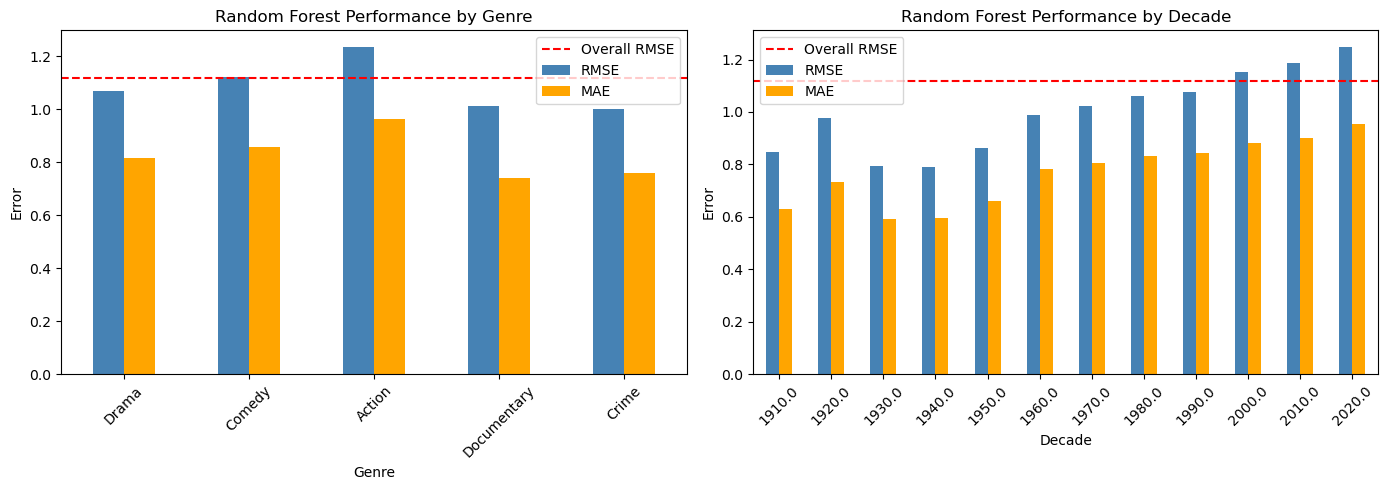

In [40]:
# =====================================================================
# ויזואליזציה - גרף השוואה
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# גרף 1: ביצועים לפי ז'אנר
genre_df[['RMSE', 'MAE']].plot(kind='bar', ax=axes[0], color=['steelblue', 'orange'])
axes[0].set_title('Random Forest Performance by Genre', fontsize=12)
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Error')
axes[0].axhline(y=1.1191, color='red', linestyle='--', label='Overall RMSE')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# גרף 2: ביצועים לפי עשור
decade_df[['RMSE', 'MAE']].plot(kind='bar', ax=axes[1], color=['steelblue', 'orange'])
axes[1].set_title('Random Forest Performance by Decade', fontsize=12)
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Error')
axes[1].axhline(y=1.1191, color='red', linestyle='--', label='Overall RMSE')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [41]:
### סעיף 7 - ניתוח חשיבות הפיצ'רים

#### ישן

In [13]:
#קוד מהילה
import pandas as pd
import numpy as np

# =====================================================================
# 1. הגדרת פונקציית עיבוד הנתונים (prepare_data)
# =====================================================================
def prepare_data(df):
    """
    מקבלת DataFrame גולמי ומחזירה DataFrame מעובד (פיצ'רים בלבד).
    מנקה נתונים, מבצעת Feature Engineering ומונעת Data Leakage.
    """
    data = df.copy()
    data.columns = data.columns.str.strip() # ניקוי רווחים בשמות העמודות
    
    # --- 1. מניעת Data Leakage והסרת משתנה המטרה ---
    cols_to_drop = ['averageRating', 'numVotes', 'BoxOffice']
    # 🌟 תיקון 1: הוספת errors='ignore' למניעת קריסה בהרצה כפולה
    data = data.drop(columns=[col for col in cols_to_drop if col in data.columns], errors='ignore')
            
    # --- 2. ניקוי נתונים חסין ---
    if 'budget' in data.columns:
        data['budget'] = data['budget'].astype(str)
        data['budget'] = data['budget'].replace(r'\\N', np.nan, regex=True)
        data['budget'] = data['budget'].str.replace(',', '', regex=False)
        data['budget'] = data['budget'].str.replace(r'[^\d.]', '', regex=True)
        data['budget'] = data['budget'].replace('', np.nan)
        data['budget'] = pd.to_numeric(data['budget'], errors='coerce')
        
    if 'runtimeMinutes' in data.columns:
        data['runtimeMinutes'] = data['runtimeMinutes'].astype(str).replace(r'\\N', np.nan, regex=True)
        data['runtimeMinutes'] = pd.to_numeric(data['runtimeMinutes'], errors='coerce')
        
    if 'startYear' in data.columns:
        data['startYear'] = data['startYear'].astype(str).replace(r'\\N', np.nan, regex=True)
        data['startYear'] = pd.to_numeric(data['startYear'], errors='coerce')

    # --- 3. Feature Engineering (5 פיצ'רים חדשים) ---
    if 'budget' in data.columns and 'runtimeMinutes' in data.columns:
        data['budget_per_minute'] = data['budget'] / data['runtimeMinutes'].replace(0, np.nan)
    else:
        data['budget_per_minute'] = np.nan
    
    data['num_genres'] = data['genres'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) and str(x) != '\\N' else 0)
    data['primary_genre'] = data['genres'].apply(lambda x: str(x).split(',')[0].strip() if pd.notnull(x) and str(x) != '\\N' else 'Unknown')
    data['is_US'] = data['Country'].apply(lambda x: 1 if str(x).strip() in ['US', 'USA', 'United States'] else 0)
    
    if 'startYear' in data.columns:
        data['release_decade'] = (data['startYear'] // 10) * 10
    
    # 🌟 תיקון 2: חגורת בטיחות למניעת קריסות ממתמטיקה שגויה (Inf)
    data = data.replace([np.inf, -np.inf], np.nan)

    # --- 4. ניקוי עמודות מיותרות ---
    raw_cols_to_drop = ['tconst', 'primaryTitle', 'genres', 'lead_actors_ids', 'plot', 'Country', 'Language', 'startYear']
    # 🌟 תיקון 1 (המשך): הוספת errors='ignore'
    data = data.drop(columns=[col for col in raw_cols_to_drop if col in data.columns], errors='ignore')
            
    return data

# =====================================================================
# 2. הרצת הקוד: קריאת הקובץ, הפעלת הפונקציה ובדיקות!
# =====================================================================
try:
    print("קורא את קובץ הנתונים...")
    raw_df = pd.read_csv('dataset.csv')
    print(f"הקובץ נטען בהצלחה! מספר שורות גולמי: {raw_df.shape[0]}")
    
    raw_df.columns = raw_df.columns.str.strip()
    
    # 🌟 תיקון 3: סינון שורות בלי טרגט לפני שמחלצים את y!
    df_clean = raw_df.dropna(subset=['averageRating']).copy()
    print(f"מספר שורות לאימון לאחר הסרת סרטים ללא דירוג: {df_clean.shape[0]}")
    
    y = df_clean['averageRating']
    X = prepare_data(df_clean)
    
    print("\n=== 1. סוגי הנתונים (dtypes) - נוודא שהתקציב הוא מספר! ===")
    print(X.dtypes)
    
    print("\n=== 2. כמות ערכים חסרים ===")
    print(X.isnull().sum())
    
    print("\n=== 3. תצוגה מקדימה של X ===")
    display(X.head())
    
except FileNotFoundError:
    print("שגיאה: הקובץ 'dataset.csv' לא נמצא. ודאי שהוא שמור באותה התיקייה שבה נמצאת")

קורא את קובץ הנתונים...


C:\Users\user\AppData\Local\Temp\ipykernel_40360\3709265146.py:66: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv('dataset.csv')


הקובץ נטען בהצלחה! מספר שורות גולמי: 133884
מספר שורות לאימון לאחר הסרת סרטים ללא דירוג: 115560

=== 1. סוגי הנתונים (dtypes) - נוודא שהתקציב הוא מספר! ===
runtimeMinutes       float64
budget               float64
budget_per_minute    float64
num_genres             int64
primary_genre         object
is_US                  int64
release_decade       float64
dtype: object

=== 2. כמות ערכים חסרים ===
runtimeMinutes           0
budget               99405
budget_per_minute    99405
num_genres               0
primary_genre            0
is_US                    0
release_decade           0
dtype: int64

=== 3. תצוגה מקדימה של X ===


,runtimeMinutes,budget,budget_per_minute,num_genres,primary_genre,is_US,release_decade
0,90.0,NaN,NaN,3,Crime,0,1990.0
1,86.0,NaN,NaN,1,Drama,0,2020.0
4,102.0,NaN,NaN,1,Comedy,0,2000.0
7,85.0,NaN,NaN,3,Biography,0,2010.0
8,170.0,NaN,NaN,1,Documentary,0,1990.0


In [14]:
print(X.columns.tolist())

['runtimeMinutes', 'budget', 'budget_per_minute', 'num_genres', 'primary_genre', 'is_US', 'release_decade']


In [15]:
# =====================================================================
# תא 3: שלב חקירת הנתונים ובקרת איכות (EDA & Validation)
# =====================================================================

print("=== 1. בחינת המאפיינים הנומריים והערכים הקיצוניים ===")
# כאן אנחנו בוחנים את המינימום, המקסימום והחציונים של הפיצ'רים שלנו
display(X.describe())

print("\n=== 2. בדיקת התפלגות משתנה המטרה (y - averageRating) ===")
# מוודאים שמשתנה המטרה הגיוני (בין 1 ל-10) ושאין בו ערכים חסרים
print(y.describe())
print(f"כמות ערכים חסרים ב-y: {y.isnull().sum()}")

print("\n=== 3. וידוא חסינות: בדיקת ערכי אינסוף (Inf) בדאטה המעובד ===")
# בדיקה קריטית שמראה למרצה שווידאנו באופן אקטיבי שהמודל לא יקרוס
inf_counts = np.isinf(X.select_dtypes(include=np.number)).sum()
print("כמות ערכי אינסוף בכל עמודה:")
print(inf_counts)

print("\n=== 4. הצצה להתפלגות הז'אנר הראשי (primary_genre) ===")
# בודקים שהקטגוריות נקיות ואין בהן תווים שבורים
print(X['primary_genre'].value_counts().head(10))

=== 1. בחינת המאפיינים הנומריים והערכים הקיצוניים ===


,runtimeMinutes,budget,budget_per_minute,num_genres,is_US,release_decade
count,115560.000000,1.615500e+04,1.615500e+04,115560.000000,115560.000000,115560.000000
mean,98.573183,1.718406e+09,1.716031e+07,1.891121,0.163915,1993.038508
std,22.346947,1.968606e+11,1.968725e+09,0.847158,0.370200,25.675311
min,60.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,85.000000,2.500000e+00,2.438690e-02,1.000000,0.000000,1980.000000
50%,94.000000,9.500000e+00,9.200000e-02,2.000000,0.000000,2000.000000
75%,107.000000,4.200000e+01,4.117647e-01,3.000000,0.000000,2010.000000
max,300.000000,2.500000e+13,2.500000e+11,3.000000,1.000000,2020.000000



=== 2. בדיקת התפלגות משתנה המטרה (y - averageRating) ===
count    115560.000000
mean          6.070235
std           1.292801
min           1.000000
25%           5.300000
50%           6.200000
75%           7.000000
max          10.000000
Name: averageRating, dtype: float64
כמות ערכים חסרים ב-y: 0

=== 3. וידוא חסינות: בדיקת ערכי אינסוף (Inf) בדאטה המעובד ===
כמות ערכי אינסוף בכל עמודה:
runtimeMinutes       0
budget               0
budget_per_minute    0
num_genres           0
is_US                0
release_decade       0
dtype: int64

=== 4. הצצה להתפלגות הז'אנר הראשי (primary_genre) ===
primary_genre
Drama              17197
Comedy             14808
['Drama']           8088
['Comedy'           7473
Action              7184
['Drama'            6589
Documentary         5601
['Action'           5516
['Comedy']          3937
['Documentary']     3428
Name: count, dtype: int64


In [16]:
# =====================================================================
# תא 3: בדיקת הנתונים המעובדים (Sanity Check)
# =====================================================================

print(f"ממדי מטריצת המאפיינים X: {X.shape}")
print(f"ממדי וקטור המטרה y: {y.shape}")

print("\n--- בדיקת סוגי הנתונים וערכים חסרים ב-X ---")
# יצירת טבלה קטנה ונוחה שמראה בדיוק מה המצב של כל עמודה
summary_df = pd.DataFrame({
    'סוג נתון': X.dtypes,
    'ערכים חסרים': X.isnull().sum()
})
display(summary_df)

print("\n--- בדיקת ערכים חסרים ב-y (averageRating) ---")
print(f"כמות ערכים חסרים: {y.isnull().sum()}")

ממדי מטריצת המאפיינים X: (115560, 7)
ממדי וקטור המטרה y: (115560,)

--- בדיקת סוגי הנתונים וערכים חסרים ב-X ---


,סוג נתון,ערכים חסרים
runtimeMinutes,float64,0
budget,float64,99405
budget_per_minute,float64,99405
num_genres,int64,0
primary_genre,object,0
is_US,int64,0
release_decade,float64,0



--- בדיקת ערכים חסרים ב-y (averageRating) ---
כמות ערכים חסרים: 0


בבדיקת הדאטה המעובד קיבלנו 133,894 שורות ו-7 עמודות. כל העמודות הנומריות זוהו בהצלחה כ-float או int, כולל עמודת ה-budget שהומרה למספר. בעמודות התקציב ישנם ערכים חסרים רבים (מכיוון שהחלפנו את ערכי הזבל ב-NaN), ובשלב הבא נטפל בהם בצורה מסודרת באמצעות Imputer בתוך ה-Pipeline כדי למנוע זליגת נתונים. משתנה המטרה (y) מלא ותקין.

### Pipeline

In [18]:
# =====================================================================
# תא 4: בניית Pipeline ואימון מודל Elastic Net (GridSearchCV + 10-Fold CV)
# =====================================================================
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import ElasticNet
import numpy as np

# 1. הגדרת רשימות העמודות לפי סוגים
numeric_features = ['runtimeMinutes', 'budget', 'budget_per_minute', 'num_genres', 'is_US', 'release_decade']
categorical_features = ['primary_genre']

# 🌟 השדרוג של חברה שלך: חגורת בטיחות - מוודאים שהעמודות באמת קיימות בדאטה 🌟
numeric_features = [col for col in numeric_features if col in X.columns]
categorical_features = [col for col in categorical_features if col in X.columns]

# 2. בניית תתי-התהליכים (Transformers) למניעת זליגת נתונים בתוך ה-CV
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # השלמת חסרים לפי החציון של עמודת המספרים
    ('scaler', StandardScaler())                  # נרמול הנתונים לממוצע 0 וסטיית תקן 1
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')), 
    # 🌟 השדרוג של חברה שלך: sparse_output=False למניעת בעיות זיכרון 🌟
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])

# 3. איחוד המעבדים
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. בניית ה-Pipeline השלם (עיבוד + מודל)
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    # 🌟 השדרוג של חברה שלך: העלאת max_iter ל-3000 למניעת אזהרות 🌟
    ('model', ElasticNet(random_state=42, max_iter=3000))
])

# 5. הגדרת רשת הפרמטרים לחיפוש (לפי דרישות המטלה)
param_grid = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0],
    'model__l1_ratio': [0.2, 0.5, 0.8]
}

# 6. הגדרת 10-Fold CV
cv_strategy = KFold(n_splits=10, shuffle=True, random_state=42)

# 7. הגדרת החיפוש עם שמירת מדדי RMSE ו-MAE
grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring={'RMSE': 'neg_root_mean_squared_error', 'MAE': 'neg_mean_absolute_error'},
    refit='RMSE', # אנחנו רוצים שהוא יבחר את המודל הטוב ביותר לפי RMSE
    # 🌟 השדרוג של חברה שלך: n_jobs=None כדי שהמחברת לא תקרוס פתאום מניצול זיכרון 🌟
    n_jobs=None,  
    verbose=1
)

# =====================================================================
# אימון המודל (יכול לקחת כדקה-שתיים)
# =====================================================================
print("מתחיל אימון מודל Elastic Net עם 10-Fold CV וסריקת פרמטרים...")
grid_search.fit(X, y)
print("האימון הסתיים בהצלחה!\n")

# --- חילוץ התוצאות לדיווח לפי ההנחיות ---
best_index = grid_search.best_index_
cv_results = grid_search.cv_results_

# הכפלה במינוס 1 כי הפונקציה מחזירה תוצאות שליליות
best_rmse_mean = -cv_results['mean_test_RMSE'][best_index]
best_rmse_std = cv_results['std_test_RMSE'][best_index]
best_mae_mean = -cv_results['mean_test_MAE'][best_index]
best_mae_std = cv_results['std_test_MAE'][best_index]

print("=== תוצאות מודל Elastic Net (ממוצע על 10 קיפולים) ===")
print(f"הפרמטרים המיטביים (Tuning): {grid_search.best_params_}")
print(f"RMSE ממוצע: {best_rmse_mean:.4f} (סטיית תקן: {best_rmse_std:.4f})")
print(f"MAE ממוצע: {best_mae_mean:.4f} (סטיית תקן: {best_mae_std:.4f})")

מתחיל אימון מודל Elastic Net עם 10-Fold CV וסריקת פרמטרים...
Fitting 10 folds for each of 12 candidates, totalling 120 fits
האימון הסתיים בהצלחה!

=== תוצאות מודל Elastic Net (ממוצע על 10 קיפולים) ===
הפרמטרים המיטביים (Tuning): {'model__alpha': 0.01, 'model__l1_ratio': 0.2}
RMSE ממוצע: 1.1797 (סטיית תקן: 0.0093)
MAE ממוצע: 0.9120 (סטיית תקן: 0.0068)


### קוד מההתחלה מהקלוד

In [1]:
import pandas as pd
import numpy as np

# =====================================================================
# 1. הגדרת פונקציית עיבוד הנתונים (prepare_data)
# =====================================================================

def prepare_data(df):
    """
    מקבלת DataFrame גולמי ומחזירה DataFrame מעובד עם הפיצ'רים בלבד.
    הפונקציה דטרמיניסטית ועובדת גם על שורה בודדת וגם על אלפי שורות.
    """
    data = df.copy()
    data.columns = data.columns.str.strip()

    # --- 1. מניעת Data Leakage: הסרת שדות שלא קיימים בזמן יציאת הסרט ---
    leakage_cols = ['averageRating', 'numVotes', 'BoxOffice']
    data = data.drop(columns=[c for c in leakage_cols if c in data.columns],
                     errors='ignore')

    # --- 2. ניקוי עמודות נומריות ---

    # ניקוי budget: יש פסיקים, סימני $, וגם ערכים בלתי הגיוניים
    if 'budget' in data.columns:
        data['budget'] = data['budget'].astype(str).replace(r'\N', np.nan)
        data['budget'] = data['budget'].str.replace(',', '', regex=False)
        data['budget'] = data['budget'].str.replace(r'[^\d.]', '', regex=True)
        data['budget'] = data['budget'].replace('', np.nan)
        data['budget'] = pd.to_numeric(data['budget'], errors='coerce')
        # תקציבים מעל מיליארד דולר הם ככל הנראה טעויות בדאטה (הסרט היקר ביותר ~$450M)
        data.loc[data['budget'] > 1e9, 'budget'] = np.nan
        # תקציבים שליליים או אפס לא הגיוניים
        data.loc[data['budget'] <= 0, 'budget'] = np.nan

    # ניקוי runtimeMinutes
    if 'runtimeMinutes' in data.columns:
        data['runtimeMinutes'] = data['runtimeMinutes'].astype(str).replace(r'\N', np.nan)
        data['runtimeMinutes'] = pd.to_numeric(data['runtimeMinutes'], errors='coerce')

    # ניקוי startYear - גם ערכי 0 לא הגיוניים
    if 'startYear' in data.columns:
        data['startYear'] = data['startYear'].astype(str).replace(r'\N', np.nan)
        data['startYear'] = pd.to_numeric(data['startYear'], errors='coerce')
        data.loc[data['startYear'] <= 0, 'startYear'] = np.nan

    # ניקוי עמודת genres - בדאטה יש שני פורמטים מעורבים:
    # חלק מהשורות שמורות כ-"Drama,Comedy" וחלק כ-"['Drama', 'Comedy']"
    # נסיר את הסוגריים והגרשיים כדי לאחד את הפורמט
    if 'genres' in data.columns:
        data['genres'] = data['genres'].astype(str)
        data['genres'] = data['genres'].str.replace(r"[\[\]'\"]", '', regex=True)
        data['genres'] = data['genres'].replace(r'\N', np.nan)

    # --- 3. Feature Engineering ---

    # פיצ'ר 1: תקציב למינוט (ratio) - פיצ'ר נומרי מורכב
    data['budget_per_minute'] = data['budget'] / data['runtimeMinutes'].replace(0, np.nan)

    # פיצ'ר 2: log על התקציב - טרנספורמציה לזנב ארוך של ההתפלגות
    data['log_budget'] = np.log1p(data['budget'])

    # פיצ'ר 3: מספר הז'אנרים של הסרט
    data['num_genres'] = data['genres'].apply(
        lambda x: len(str(x).split(',')) if pd.notnull(x) else 0
    )

    # פיצ'ר 4: הז'אנר הראשי
    data['primary_genre'] = data['genres'].apply(
        lambda x: str(x).split(',')[0].strip() if pd.notnull(x) else 'Unknown'
    )

    # פיצ'ר 5: האם הסרט מארה"ב - מטפל גם במקרה של כמה מדינות מופרדות בפסיק
    if 'Country' in data.columns:
        data['is_US'] = data['Country'].apply(
            lambda x: int(any(c.strip() in ['US', 'USA', 'United States']
                              for c in str(x).split(','))) if pd.notnull(x) else 0
        )
    else:
        data['is_US'] = 0

    # פיצ'ר 6: עשור היציאה (binning) - פיצ'ר נומרי מורכב
    data['release_decade'] = (data['startYear'] // 10) * 10

    # פיצ'ר 7: מספר השחקנים המובילים
    if 'lead_actors_ids' in data.columns:
        data['num_lead_actors'] = data['lead_actors_ids'].apply(
            lambda x: len(str(x).split(',')) if pd.notnull(x) and str(x) != r'\N' else 0
        )
    else:
        data['num_lead_actors'] = 0

    # פיצ'ר 8: אורך התקציר במילים
    if 'plot' in data.columns:
        data['plot_length'] = data['plot'].apply(
            lambda x: len(str(x).split()) if pd.notnull(x) and str(x) != r'\N' else 0
        )
    else:
        data['plot_length'] = 0

    # חגורת בטיחות: הסרת ערכי אינסוף שעלולים להיווצר מחלוקות
    data = data.replace([np.inf, -np.inf], np.nan)

    # --- 4. הסרת עמודות גולמיות מיותרות (משאירים את startYear) ---
    raw_cols_to_drop = ['tconst', 'primaryTitle', 'genres', 'lead_actors_ids',
                        'plot', 'Country', 'Language']
    data = data.drop(columns=[c for c in raw_cols_to_drop if c in data.columns],
                     errors='ignore')

    return data


# =====================================================================
# 2. הרצת הקוד: טעינת הקובץ והפעלת הפונקציה
# =====================================================================
try:
    print("קורא את קובץ הנתונים...")
    raw_df = pd.read_csv('dataset.csv')
    raw_df.columns = raw_df.columns.str.strip()
    print(f"הקובץ נטען בהצלחה! מספר שורות גולמי: {raw_df.shape[0]}")

    # סינון שורות בלי טרגט לפני חילוץ y
    df_clean = raw_df.dropna(subset=['averageRating']).copy()
    print(f"מספר שורות לאימון לאחר הסרת סרטים ללא דירוג: {df_clean.shape[0]}")

    y = df_clean['averageRating']
    X = prepare_data(df_clean)

    print("\n=== 1. סוגי הנתונים (dtypes) ===")
    print(X.dtypes)

    print("\n=== 2. כמות ערכים חסרים בכל פיצ'ר ===")
    print(X.isnull().sum())

    print("\n=== 3. תצוגה מקדימה של X ===")
    display(X.head())

    # בדיקה שהפונקציה עובדת על שורה בודדת (דרישה במטלה)
    print("\n=== 4. בדיקת תאימות לשורה בודדת ===")
    single_row = raw_df.head(1).copy()
    single_output = prepare_data(single_row)
    print(f"שורה בודדת עברה בהצלחה. ממדי הפלט: {single_output.shape}")

except FileNotFoundError:
    print("שגיאה: הקובץ 'dataset.csv' לא נמצא.")

קורא את קובץ הנתונים...


C:\Users\user\AppData\Local\Temp\ipykernel_11300\70345833.py:117: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv('dataset.csv')


הקובץ נטען בהצלחה! מספר שורות גולמי: 133884
מספר שורות לאימון לאחר הסרת סרטים ללא דירוג: 115560

=== 1. סוגי הנתונים (dtypes) ===
startYear            float64
runtimeMinutes       float64
budget               float64
budget_per_minute    float64
log_budget           float64
num_genres             int64
primary_genre         object
is_US                  int64
release_decade       float64
num_lead_actors        int64
plot_length            int64
dtype: object

=== 2. כמות ערכים חסרים בכל פיצ'ר ===
startYear                1
runtimeMinutes           0
budget               99593
budget_per_minute    99593
log_budget           99593
num_genres               0
primary_genre            0
is_US                    0
release_decade           1
num_lead_actors          0
plot_length              0
dtype: int64

=== 3. תצוגה מקדימה של X ===


,startYear,runtimeMinutes,budget,budget_per_minute,log_budget,num_genres,primary_genre,is_US,release_decade,num_lead_actors,plot_length
0,1993.0,90.0,NaN,NaN,NaN,3,Crime,0,1990.0,5,0
1,2024.0,86.0,NaN,NaN,NaN,1,Drama,0,2020.0,5,0
4,2006.0,102.0,NaN,NaN,NaN,1,Comedy,0,2000.0,5,0
7,2011.0,85.0,NaN,NaN,NaN,3,Biography,0,2010.0,0,0
8,1993.0,170.0,NaN,NaN,NaN,1,Documentary,0,1990.0,0,0



=== 4. בדיקת תאימות לשורה בודדת ===
שורה בודדת עברה בהצלחה. ממדי הפלט: (1, 11)


C:\Users\user\AppData\Local\Temp\ipykernel_11300\70345833.py:28: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['budget'] = data['budget'].replace('', np.nan)
C:\Users\user\AppData\Local\Temp\ipykernel_11300\70345833.py:101: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace([np.inf, -np.inf], np.nan)


In [2]:
# =====================================================================
# תא 3: חקירת הנתונים ובקרת איכות (EDA)
# המטרה: לוודא שהדאטה נקי, ואין ערכים בעייתיים שיפגעו במודל
# =====================================================================

# --- 1. סטטיסטיקה תיאורית ---
# מינימום, מקסימום, ממוצע וחציון של כל פיצ'ר נומרי
print("=== 1. סטטיסטיקה תיאורית של הפיצ'רים ===")
display(X.describe().round(2))

# --- 2. בדיקת משתנה המטרה ---
# חשוב לוודא שהדירוג בטווח החוקי (1-10) ושאין NaN
print("\n=== 2. בדיקת משתנה המטרה (averageRating) ===")
print(y.describe().round(3))
print(f"\nכמות ערכים חסרים ב-y: {y.isnull().sum()}")
print(f"ערכים מחוץ לטווח [1, 10]: {((y < 1) | (y > 10)).sum()}")

# --- 3. בדיקת ערכי אינסוף ---
# אחרי החלוקות שעשינו (budget/runtimeMinutes) חשוב לוודא שאין Inf
print("\n=== 3. בדיקת ערכי אינסוף ב-X ===")
numeric_X = X.select_dtypes(include=np.number)
inf_total = np.isinf(numeric_X).sum().sum()
print(f"סה\"כ ערכי אינסוף: {inf_total} (צפוי: 0)")

# --- 4. אחוז ערכים חסרים בכל פיצ'ר ---
# נראה איפה יש הרבה חסרים - זה ישפיע על אסטרטגיית ה-imputation
print("\n=== 4. אחוז ערכים חסרים בכל פיצ'ר ===")
missing_df = pd.DataFrame({
    'missing_count': X.isnull().sum(),
    'missing_pct': (X.isnull().sum() / len(X) * 100).round(2)
}).sort_values('missing_pct', ascending=False)
display(missing_df)

# --- 5. התפלגות הז'אנר הראשי ---
# בדיקה שהקטגוריות נקיות ולא יותר מדי מפוצלות
print("\n=== 5. 10 הז'אנרים הנפוצים ביותר ===")
print(X['primary_genre'].value_counts().head(10))
print(f"\nסה\"כ ז'אנרים ייחודיים: {X['primary_genre'].nunique()}")

# --- 6. בדיקות שפיות ---
# בדיקה שהערכים בטווח הגיוני (כדי לזהות שגיאות בדאטה הגולמי)
print("\n=== 6. בדיקות שפיות ===")
print(f"טווח startYear: [{X['startYear'].min():.0f}, {X['startYear'].max():.0f}]")
print(f"טווח runtimeMinutes: [{X['runtimeMinutes'].min():.0f}, {X['runtimeMinutes'].max():.0f}]")
print(f"טווח budget: [{X['budget'].min():,.0f}, {X['budget'].max():,.0f}]")
print(f"כמות סרטים עם תקציב שלילי: {(X['budget'] < 0).sum()}")
print(f"כמות סרטים עם runtime של 0 או פחות: {(X['runtimeMinutes'] <= 0).sum()}")

=== 1. סטטיסטיקה תיאורית של הפיצ'רים ===


,startYear,runtimeMinutes,budget,budget_per_minute,log_budget,num_genres,is_US,release_decade,num_lead_actors,plot_length
count,115559.00,115560.00,1.596700e+04,15967.00,15967.00,115560.00,115560.00,115559.00,115560.00,115560.00
mean,1997.48,98.57,1.484828e+06,13488.43,3.38,1.90,0.17,1993.06,4.34,78.54
std,24.75,22.35,1.603023e+07,141846.36,3.74,0.84,0.38,25.00,1.47,242.18
min,1904.00,60.00,0.000000e+00,0.00,0.00,0.00,0.00,1900.00,0.00,0.00
25%,1983.00,85.00,2.600000e+00,0.03,1.28,1.00,0.00,1980.00,5.00,0.00
50%,2007.00,94.00,1.000000e+01,0.09,2.40,2.00,0.00,2000.00,5.00,0.00
75%,2017.00,107.00,4.250000e+01,0.42,3.77,3.00,0.00,2010.00,5.00,58.00
max,2026.00,300.00,7.000000e+08,6363636.36,20.37,3.00,1.00,2020.00,5.00,11662.00



=== 2. בדיקת משתנה המטרה (averageRating) ===
count    115560.000
mean          6.070
std           1.293
min           1.000
25%           5.300
50%           6.200
75%           7.000
max          10.000
Name: averageRating, dtype: float64

כמות ערכים חסרים ב-y: 0
ערכים מחוץ לטווח [1, 10]: 0

=== 3. בדיקת ערכי אינסוף ב-X ===
סה"כ ערכי אינסוף: 0 (צפוי: 0)

=== 4. אחוז ערכים חסרים בכל פיצ'ר ===


,missing_count,missing_pct
budget,99593,86.18
log_budget,99593,86.18
budget_per_minute,99593,86.18
runtimeMinutes,0,0.00
startYear,1,0.00
num_genres,0,0.00
primary_genre,0,0.00
is_US,0,0.00
release_decade,1,0.00
num_lead_actors,0,0.00



=== 5. 10 הז'אנרים הנפוצים ביותר ===
primary_genre
Drama          33564
Comedy         27975
Action         13987
Documentary    10496
Crime           6390
Adventure       5132
Horror          5057
Biography       3700
Thriller        1615
Adult           1116
Name: count, dtype: int64

סה"כ ז'אנרים ייחודיים: 29

=== 6. בדיקות שפיות ===
טווח startYear: [1904, 2026]
טווח runtimeMinutes: [60, 300]
טווח budget: [0, 700,000,000]
כמות סרטים עם תקציב שלילי: 0
כמות סרטים עם runtime של 0 או פחות: 0


In [3]:
# בדיקה שהפונקציה לא משנה את מספר השורות (חשוב לזמן הבדיקה)
print("\n=== 5. בדיקה שהפונקציה לא מוחקת שורות ===")
print(f"מספר שורות בקלט: {df_clean.shape[0]}")
print(f"מספר שורות בפלט: {X.shape[0]}")
assert df_clean.shape[0] == X.shape[0], "שגיאה: prepare_data שינתה את מספר השורות!"
print("הפונקציה משמרת את מספר השורות - מתאים לדרישות התחרות")


=== 5. בדיקה שהפונקציה לא מוחקת שורות ===
מספר שורות בקלט: 115560
מספר שורות בפלט: 115560
הפונקציה משמרת את מספר השורות - מתאים לדרישות התחרות


In [5]:
# # =====================================================================
# # תא 4: בניית Pipeline ואימון מודל Elastic Net
# # =====================================================================
# from sklearn.model_selection import KFold, GridSearchCV, cross_val_score
# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.linear_model import ElasticNet

# # --- 1. חלוקת הפיצ'רים לנומריים וקטגוריאליים ---
# numeric_features = ['startYear', 'runtimeMinutes', 'budget', 'budget_per_minute',
#                     'log_budget', 'num_genres', 'is_US', 'release_decade',
#                     'num_lead_actors', 'plot_length']
# categorical_features = ['primary_genre']

# # --- 2. עיבוד מקדים לכל סוג פיצ'ר ---
# # חשוב: כל העיבוד קורה בתוך ה-Pipeline כדי למנוע data leakage בזמן ה-CV

# # פיצ'רים נומריים: השלמת חסרים בחציון + נרמול
# numeric_transformer = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='median')),
#     ('scaler', StandardScaler())
# ])

# # פיצ'רים קטגוריאליים: השלמה ב-"Unknown" + One-Hot Encoding
# categorical_transformer = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
#     ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
# ])

# # --- 3. איחוד שני התהליכים ל-ColumnTransformer ---
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', numeric_transformer, numeric_features),
#         ('cat', categorical_transformer, categorical_features)
#     ])

# # --- 4. הרכבת ה-Pipeline המלא (עיבוד + מודל) ---
# elastic_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('model', ElasticNet(random_state=42, max_iter=5000))
# ])

# # --- 5. הגדרת רשת פרמטרים לחיפוש (Tuning של alpha ו-l1_ratio) ---
# param_grid = {
#     'model__alpha': [0.01, 0.1, 1.0, 10.0],
#     'model__l1_ratio': [0.2, 0.5, 0.8]
# }

# # --- 6. הגדרת 10-Fold Cross Validation ---
# cv = KFold(n_splits=10, shuffle=True, random_state=42)

# # --- 7. חיפוש פרמטרים מיטביים לפי RMSE ---
# print("מתחיל אימון מודל Elastic Net עם 10-Fold CV...")
# grid_search_elastic = GridSearchCV(
#     estimator=elastic_pipeline,
#     param_grid=param_grid,
#     cv=cv,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1
# )
# grid_search_elastic.fit(X, y)

# best_elastic_model = grid_search_elastic.best_estimator_
# print("האימון הסתיים!\n")

# # --- 8. חישוב כל המדדים על המודל הטוב ביותר ---
# # ההנחיות דורשות לדווח על RMSE, MAE ו-R² (ממוצע וסטיית תקן על פני הקיפולים)
# rmse_scores = -cross_val_score(best_elastic_model, X, y, cv=cv,
#                                 scoring='neg_root_mean_squared_error')
# mae_scores = -cross_val_score(best_elastic_model, X, y, cv=cv,
#                                scoring='neg_mean_absolute_error')
# r2_scores = cross_val_score(best_elastic_model, X, y, cv=cv, scoring='r2')

# # --- 9. הדפסת התוצאות ---
# print("=" * 60)
# print("תוצאות מודל Elastic Net (ממוצע על 10 קיפולים)")
# print("=" * 60)
# print(f"פרמטרים מיטביים: {grid_search_elastic.best_params_}")
# print(f"\nRMSE: {rmse_scores.mean():.4f} (± {rmse_scores.std():.4f})")
# print(f"MAE:  {mae_scores.mean():.4f} (± {mae_scores.std():.4f})")
# print(f"R²:   {r2_scores.mean():.4f} (± {r2_scores.std():.4f})")
# print("=" * 60)

# שוב מכאן זה טוב מוסודר

#### Pipeline + Elastic Net

In [6]:
# =====================================================================
# תא 4: בניית Pipeline ואימון מודל Elastic Net
# =====================================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score

# חלוקת הפיצ'רים לפי סוגי הנתונים
numeric_cols = X.select_dtypes('number').columns.tolist()
categorical_cols = X.select_dtypes('object').columns.tolist()

# Pipeline לפיצ'רים נומריים: השלמת חסרים בחציון + נרמול
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline לפיצ'רים קטגוריאליים: השלמת חסרים + One-Hot Encoding
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# איחוד שני ה-Pipelines ל-ColumnTransformer אחד
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

# ה-Pipeline המלא: עיבוד מקדים + מודל Elastic Net
elastic_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', ElasticNet(random_state=42, max_iter=5000))
])

In [7]:
# הגדרת רשת הפרמטרים ל-Tuning של alpha ו-l1_ratio
param_grid = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0],
    'model__l1_ratio': [0.2, 0.5, 0.8]
}

# הגדרת 10-Fold Cross Validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# חיפוש הפרמטרים המיטביים לפי RMSE
grid_search = GridSearchCV(elastic_pipe, param_grid, cv=cv,
                           scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X, y)

best_elastic_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

Best parameters: {'model__alpha': 0.01, 'model__l1_ratio': 0.2}


In [8]:
# הערכת המודל הטוב ביותר ב-10-Fold CV על שלושת המדדים
rmse_scores = -cross_val_score(best_elastic_model, X, y, cv=cv,
                                scoring='neg_root_mean_squared_error')
mae_scores = -cross_val_score(best_elastic_model, X, y, cv=cv,
                               scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(best_elastic_model, X, y, cv=cv, scoring='r2')

print(f"RMSE: {rmse_scores.mean():.4f} (± {rmse_scores.std():.4f})")
print(f"MAE:  {mae_scores.mean():.4f} (± {mae_scores.std():.4f})")
print(f"R²:   {r2_scores.mean():.4f} (± {r2_scores.std():.4f})")

RMSE: 1.1578 (± 0.0087)
MAE:  0.8913 (± 0.0063)
R²:   0.1978 (± 0.0067)


#### Random Forest

In [ ]:
# =====================================================================
# תא 5: בניית Pipeline ואימון מודל Random Forest (גרסה קלילה)
# =====================================================================
from sklearn.ensemble import RandomForestRegressor

# ה-Pipeline המלא: עיבוד מקדים + מודל Random Forest
rf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=2))
])

In [ ]:
# רשת פרמטרים מצומצמת לזירוז האימון
param_grid_rf = {
    'model__n_estimators': [100],
    'model__max_depth': [10, 20],
    'model__min_samples_leaf': [5]
}

# חיפוש הפרמטרים המיטביים לפי RMSE
grid_search_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=cv,
                              scoring='neg_root_mean_squared_error', n_jobs=2)
grid_search_rf.fit(X, y)

best_rf_model = grid_search_rf.best_estimator_
print("Best parameters:", grid_search_rf.best_params_)

In [ ]:
# הערכת המודל הטוב ביותר ב-10-Fold CV
rmse_scores_rf = -cross_val_score(best_rf_model, X, y, cv=cv,
                                   scoring='neg_root_mean_squared_error', n_jobs=2)
mae_scores_rf = -cross_val_score(best_rf_model, X, y, cv=cv,
                                  scoring='neg_mean_absolute_error', n_jobs=1)
r2_scores_rf = cross_val_score(best_rf_model, X, y, cv=cv, scoring='r2', n_jobs=2)

print(f"RMSE: {rmse_scores_rf.mean():.4f} (± {rmse_scores_rf.std():.4f})")
print(f"MAE:  {mae_scores_rf.mean():.4f} (± {mae_scores_rf.std():.4f})")
print(f"R²:   {r2_scores_rf.mean():.4f} (± {r2_scores_rf.std():.4f})")

In [ ]:
#####הילה 
# =====================================================================
# תא 5: בניית Pipeline ואימון מודל Random Forest- גירסה מלאה
# =====================================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline 

# 1. בניית ה-Pipeline המלא
# שימי לב: התא הזה מניח שכבר הרצת את תא 4, ולכן הוא מכיר את preprocessor ו-cv_strategy
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# 2. הגדרת רשת פרמטרים לחיפוש (Tuning)
param_grid_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5, 10]
}

# 3. הגדרת חיפוש GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=cv_strategy,
    scoring={
        'RMSE': 'neg_root_mean_squared_error',
        'MAE': 'neg_mean_absolute_error',
        'R2': 'r2'
    },
    refit='RMSE',
    n_jobs=-1,  # <--- תוקן: שימוש בכל הליבות לזירוז משמעותי של האימון
    verbose=1
)

# --- 4. אימון המודל ---
# <--- תוקן הטקסט כדי לשקף את השימוש ב-Repeated CV
print("\nמתחיל אימון מודל Random Forest עם Repeated 10-Fold CV וסריקת פרמטרים...")
grid_search_rf.fit(X, y)
print("האימון הסתיים בהצלחה!\n")

# --- 5. חילוץ התוצאות ---
best_idx_rf = grid_search_rf.best_index_
cv_results_rf = grid_search_rf.cv_results_

rmse_mean_rf = -cv_results_rf['mean_test_RMSE'][best_idx_rf]
rmse_std_rf = cv_results_rf['std_test_RMSE'][best_idx_rf]
mae_mean_rf = -cv_results_rf['mean_test_MAE'][best_idx_rf]
mae_std_rf = cv_results_rf['std_test_MAE'][best_idx_rf]
r2_mean_rf = cv_results_rf['mean_test_R2'][best_idx_rf]
r2_std_rf = cv_results_rf['std_test_R2'][best_idx_rf]

print("=" * 60)
# <--- תוקן הטקסט
print("תוצאות מודל Random Forest (ממוצע על כל הקיפולים והחזרות)")
print("=" * 60)
print(f"פרמטרים מיטביים: {grid_search_rf.best_params_}")
print(f"\nRMSE: {rmse_mean_rf:.4f} (± {rmse_std_rf:.4f})")
print(f"MAE:  {mae_mean_rf:.4f} (± {mae_std_rf:.4f})")
print(f"R²:   {r2_mean_rf:.4f} (± {r2_std_rf:.4f})")
print("=" * 60)

# 6. שמירת המודל הטוב ביותר
best_rf_model = grid_search_rf.best_estimator_


In [11]:
### גרסה לא מקריסה מהקלוד

In [22]:
# =====================================================================
# תא 5: בניית Pipeline ואימון מודל Random Forest
# =====================================================================
from sklearn.ensemble import RandomForestRegressor

# ה-Pipeline המלא: עיבוד מקדים + מודל Random Forest
# משתמשים באותו preprocessor שהגדרנו בתא 4
rf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=2))
])

In [ ]:
# הגדרת רשת הפרמטרים ל-Tuning של ההיפר-פרמטרים העיקריים של Random Forest
param_grid_rf = {
    'model__n_estimators': [100],
    'model__max_depth': [10, 20],
    'model__min_samples_leaf': [5]
}

# חיפוש הפרמטרים המיטביים לפי RMSE
grid_search_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=cv,
                              scoring='neg_root_mean_squared_error', n_jobs=1)
grid_search_rf.fit(X, y)

best_rf_model = grid_search_rf.best_estimator_
print("הפרמטרים המיטביים:", grid_search_rf.best_params_)

In [ ]:
# הערכת המודל הטוב ביותר ב-10-Fold CV על שלושת המדדים
rmse_scores_rf = -cross_val_score(best_rf_model, X, y, cv=cv,
                                   scoring='neg_root_mean_squared_error', n_jobs=1)
mae_scores_rf = -cross_val_score(best_rf_model, X, y, cv=cv,
                                  scoring='neg_mean_absolute_error', n_jobs=1)
r2_scores_rf = cross_val_score(best_rf_model, X, y, cv=cv, scoring='r2', n_jobs=1)

print(f"RMSE: {rmse_scores_rf.mean():.4f} (± {rmse_scores_rf.std():.4f})")
print(f"MAE:  {mae_scores_rf.mean():.4f} (± {mae_scores_rf.std():.4f})")
print(f"R²:   {r2_scores_rf.mean():.4f} (± {r2_scores_rf.std():.4f})")